In [1]:
# 这会将您的 Google Drive 挂载到 Colab 虚拟机。
# from google.colab import drive
# drive.mount('/content/drive')

# TODO: 输入要在 Drive 中保存解压后的作业文件夹的文件夹名称，
# 例如 'cs231n/assignments/assignment1/'
FOLDERNAME = None
# assert FOLDERNAME is not None, "[!] Enter the foldername."

# 现在我们要挂载您的 Drive，这能确保 Colab 虚拟机的 Python解释器
# 可以从中加载 python 文件。
import sys
# sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 如果 Drive 中不存在 CIFAR-10 数据集，这将下载它。
# %cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
# !bash get_datasets.sh
# %cd /content/drive/My\ Drive/$FOLDERNAME

print("Detected local environment. Skipping Google Colab setup code.")

Detected local environment. Skipping Google Colab setup code.


# 多分类支持向量机（SVM）练习

*完成并提交此工作表（包括其输出和任何在工作表外的支持代码）作为你的作业提交。更多细节请参见课程网站上的[作业页面](http://vision.stanford.edu/teaching/cs231n/assignments.html)。*

在这个练习中，你将：

- 为 SVM 实现一个完全向量化的**损失函数**
- 实现其**解析梯度**的完全向量化表达式
- 使用数值梯度**检查你的实现**
- 使用验证集来**调整学习率和正则化**强度
- 使用 **SGD**（随机梯度下降）**优化**损失函数
- **可视化**最终学习到的权重

<details><summary>英文原文</summary>

# Multiclass Support Vector Machine exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the SVM
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights

</details>

In [2]:
# 运行本笔记本的一些设置代码。
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# 这是一些魔法命令，使 matplotlib 图像在笔记本内联显示
# 而不是在新窗口中显示。
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 设置图像默认大小
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# 还有一些魔法命令，使笔记本能自动重新加载外部 python 模块；
# 参考 http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 数据加载和预处理

<details><summary>英文原文</summary>

## CIFAR-10 Data Loading and Preprocessing

</details>

In [3]:
# 加载原始 CIFAR-10 数据。
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# 清理变量以防止多次加载数据（可能导致内存问题）
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# 做一个健壮性检查，打印训练和测试数据的大小。
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


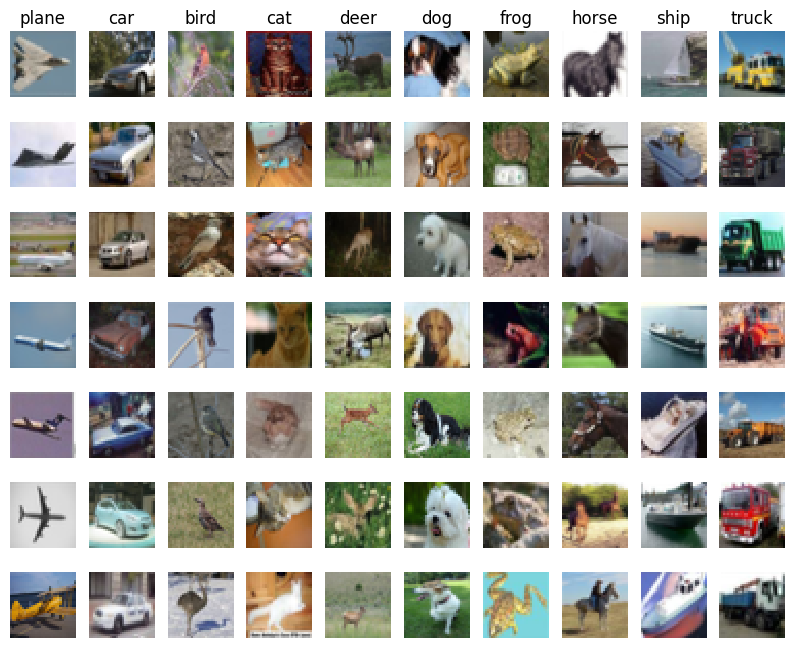

In [4]:
# 可视化数据集中的一些样本。
# 我们展示每个类别的部分训练图像样本。
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [5]:
# 将数据分为训练集、验证集和测试集。此外我们还会
# 创建一个小的开发集作为训练集的子集；
# 用于开发阶段以加快代码运行速度。
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# 验证集将是原始训练集中的 num_validation 个样本。
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# 训练集将是原始训练集中的前 num_train 个样本。
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# 我们还会创建一个开发集，是训练集的一个小子集。
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# 测试集是原始测试集的前 num_test 个样本。
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [6]:
# 预处理：将图像数据重塑为行向量
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# 做一个健壮性检查，打印数据的形状
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


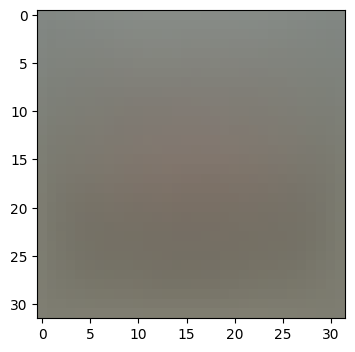

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [7]:
# 预处理：减去均值图像
# 第一步：根据训练数据计算均值图像
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # 打印前几个元素
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # 可视化均值图像
plt.show()

# 第二步：从训练和测试数据中减去均值图像
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# 第三步：添加偏置维度（全为 1），这样 SVM 只需优化一个权重矩阵 W。
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## SVM 分类器

这一部分的代码将全部写在 `cs231n/classifiers/linear_svm.py` 中。

如你所见，我们已经预先填充了 `svm_loss_naive` 函数，它使用 for 循环来计算多分类 SVM 损失函数。

<details><summary>英文原文</summary>

## SVM Classifier

Your code for this section will all be written inside `cs231n/classifiers/linear_svm.py`. 

As you can see, we have prefilled the function `svm_loss_naive` which uses for loops to evaluate the multiclass SVM loss function. 

</details>

In [8]:
# 评估我们为您提供的损失函数的朴素实现：
from cs231n.classifiers.linear_svm import svm_loss_naive
import time

# 生成一个随机的 SVM 权重矩阵，数值较小
W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 9.051891


上面函数返回的 `grad` 目前全是零。推导并实现 SVM 代价函数的梯度，并将其内联实现到 `svm_loss_naive` 函数中。你会发现将新代码穿插在现有函数中会很有帮助。

为了检查你是否正确实现了梯度，你可以数值估算损失函数的梯度，并将数值估算结果与你计算的梯度进行比较。我们为你提供了执行此操作的代码：

<details><summary>英文原文</summary>

The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the SVM cost function and implement it inline inside the function `svm_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

</details>

In [9]:
# 一旦您实现了梯度，请使用下面的代码重新计算它
# 并使用我们为您提供的函数进行梯度检查

# 在 W 处计算损失及其梯度。
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

# 在几个随机选择的维度上数值计算梯度，并
# 将它们与您解析计算的梯度进行比较。在所有维度上，数字应该几乎完全匹配。
from cs231n.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# 打开正则化再次进行梯度检查
# 您没有忘记正则化梯度吧？
loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

数值梯度: -22.215721 解析梯度: -22.215721, 相对误差: 1.026264e-11
数值梯度: 7.205823 解析梯度: 7.205823, 相对误差: 3.383284e-11
数值梯度: -45.694465 解析梯度: -45.694465, 相对误差: 1.814358e-12
数值梯度: 6.690901 解析梯度: 6.690901, 相对误差: 7.066028e-11
数值梯度: 12.432542 解析梯度: 12.432542, 相对误差: 4.853356e-11
数值梯度: 14.534303 解析梯度: 14.534303, 相对误差: 4.858114e-12
数值梯度: 2.953069 解析梯度: 2.953069, 相对误差: 1.847674e-10
数值梯度: -12.682224 解析梯度: -12.682224, 相对误差: 2.930335e-11
数值梯度: 30.383371 解析梯度: 30.383371, 相对误差: 3.020933e-12
数值梯度: 23.672783 解析梯度: 23.672783, 相对误差: 7.824581e-12
数值梯度: -28.366201 解析梯度: -28.366201, 相对误差: 2.481697e-11
数值梯度: -4.034517 解析梯度: -4.034517, 相对误差: 7.283737e-11
数值梯度: -9.685954 解析梯度: -9.685954, 相对误差: 1.207584e-11
数值梯度: 19.307422 解析梯度: 19.307422, 相对误差: 2.034619e-11
数值梯度: -31.321351 解析梯度: -31.321351, 相对误差: 1.239852e-11
数值梯度: 29.040193 解析梯度: 29.040193, 相对误差: 3.265808e-13
数值梯度: 19.587905 解析梯度: 19.587905, 相对误差: 2.116956e-11
数值梯度: -10.059239 解析梯度: -10.059239, 相对误差: 1.279886e-11
数值梯度: -12.426021 解析梯度: -12.426021, 相对误差: 4.413323e-11
数值梯度

**内嵌问题 1**

有可能在梯度检查中，偶尔会有一个维度的数值不完全匹配。这种差异可能是什么原因造成的？这是一个值得担心的问题吗？给出一个简单的一维例子，说明梯度检查可能会在哪里失败？改变容错率（margin）会如何影响这种情况发生的频率？*提示：SVM 损失函数严格来说是不可微的*

$\color{blue}{\textit 你的答案:}$
max(0, x)函数在x=0处是一个不可微的折点。在进行数值梯度检查时，如果使用步长h恰好跨越了这个折点，通过有限差分计算的数值梯度就会与直接求导的解析梯度产生明显的数值差距。
这个问题不需要担心，在深度学习和机器学习中有很多类似的函数如ReLu激活函数，用的都好好的（）
假设一维损失f(x)=max(0,x)。在 $x = -10^{-3}$ 处计算梯度，此时使用步长$h = 10^{-2}$计算。解析梯度会在x<0的情况下给出0。而数值梯度会是0.45左右。两者相差很大，会导致梯度检查失败。
容错率只起到了平移边界的作用，不会改变落入不可微邻域的概率密度，因此改变 容错率不会明显影响这种情况发生的频率。

<details><summary>英文原文</summary>

**Inline Question 1**

It is possible that once in a while a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a gradient check could fail? How would change the margin affect of the frequency of this happening? *Hint: the SVM loss function is not strictly speaking differentiable*

$\color{blue}{\textit Your Answer:}$ 
- **Cause**: The discrepancy is caused by the non-differentiable "kink" at zero in the SVM's hinge loss function $\max(0, x)$. When the numerical gradient's step $h$ crosses this boundary (e.g., evaluating at $x-h < 0$ and $x+h > 0$), it yields a smoothed slope, which disagrees with the analytic subgradient step that sharply outputs 0 or 1.
- **Reason for concern**: No, it is not a concern. Using subgradients is a well-established practice in optimization on non-smooth functions like ReLUs and Max margins, and Stochastic Gradient Descent still converges robustly.
- **1D Example**: Let $f(x) = \max(0, x)$, evaluate at $x = -0.01$ with $h = 0.02$. The analytic gradient is 0. The numerical gradient is $\frac{\max(0, 0.01) - \max(0, -0.03)}{0.04} = 0.25$. Mismatch!
- **Margin effect**: Changing the margin $\Delta$ simply shifts the loss function horizontally. Therefore, it translates the problematic non-differentiable point instead of altering its nature, having basically no effect on the frequency of these mismatches given an arbitrary data spread.

</details>

In [10]:
# 接下来实现 svm_loss_vectorized 函数；目前只需计算损失；
# 稍后我们将实现梯度。
tic = time.time()
loss_naive, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.linear_svm import svm_loss_vectorized
tic = time.time()
loss_vectorized, _ = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# 损失应该一致，但您的向量化实现应该快得多。
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 9.051891e+00 computed in 0.020570s
Vectorized loss: 9.051891e+00 computed in 0.002727s
difference: 0.000000


In [11]:
# 完成 svm_loss_vectorized 的实现，并以向量化方式计算损失函数的梯度。

# 朴素实现和向量化实现应该一致，但向量化版本仍然快得多。
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# 损失是一个数值，所以很容易比较两种实现计算得到的值。
# 另一方面，梯度是一个矩阵，所以我们使用 Frobenius 范数来比较它们。
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.020753s
Vectorized loss and gradient: computed in 0.002241s
difference: 0.000000


### 随机梯度下降 (SGD)

既然我们已经有了向量化且高效的损失函数和梯度表达式，并且我们的梯度与数值梯度匹配。因此，我们要准备使用 SGD 来最小化损失。这部分的代码将写在 `cs231n/classifiers/linear_classifier.py` 中。

<details><summary>英文原文</summary>

### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `cs231n/classifiers/linear_classifier.py`.

</details>

In [12]:
# 在文件 linear_classifier.py 中，实现函数 LinearClassifier.train() 中的 SGD，
# 然后用下面的代码运行它。
from cs231n.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 789.480149
iteration 100 / 1500: loss 288.346581
iteration 200 / 1500: loss 107.713129
iteration 300 / 1500: loss 42.672275
iteration 400 / 1500: loss 19.110869
iteration 500 / 1500: loss 10.805117
iteration 600 / 1500: loss 7.178927
iteration 700 / 1500: loss 5.924725
iteration 800 / 1500: loss 5.841759
iteration 900 / 1500: loss 5.360809
iteration 1000 / 1500: loss 5.272193
iteration 1100 / 1500: loss 5.519796
iteration 1200 / 1500: loss 5.125085
iteration 1300 / 1500: loss 5.455218
iteration 1400 / 1500: loss 5.549927
That took 3.740354s


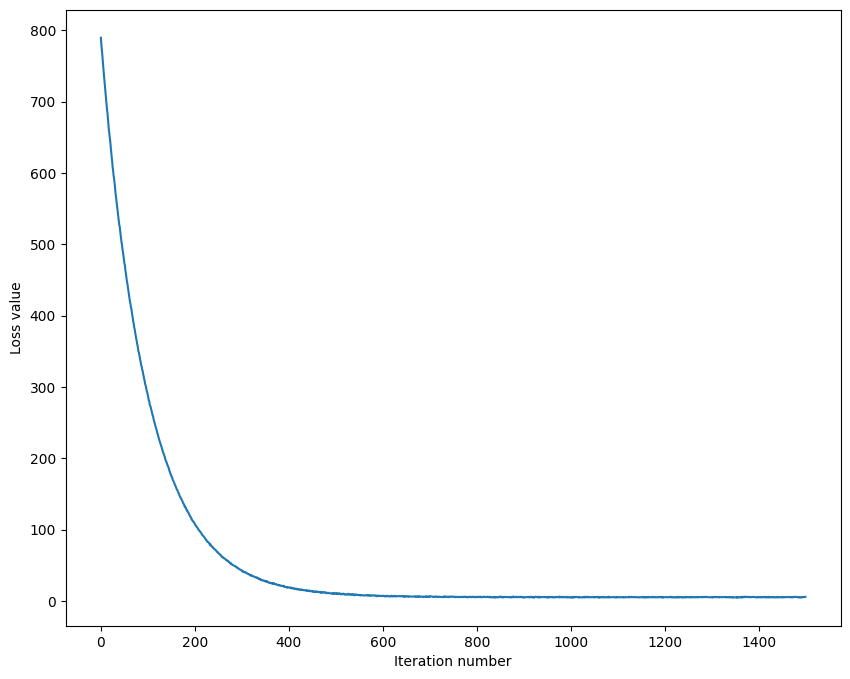

In [13]:
# 一个有用的调试策略是绘制损失随迭代次数的变化曲线：
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [14]:
# 编写 LinearSVM.predict 函数，并在训练集和验证集上评估性能
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.374531
validation accuracy: 0.376000


In [15]:
# 使用验证集调优超参数（正则化强度和学习率）。您应该尝试不同范围的学习率和正则化强度；
# 如果您仔细调参，应该能在验证集上得到约 0.39 (> 0.385) 的分类准确率。

# 注意：在超参数搜索过程中可能会看到运行时/溢出警告。
# 这可能是极端值导致的，不是 bug。

# results 是一个字典，将 (learning_rate, regularization_strength) 元组映射到
# (training_accuracy, validation_accuracy) 元组。准确率即正确分类样本的比例。
results = {}
best_val = -1   # 目前见过的最高验证准确率。
best_svm = None # 达到最高验证准确率的 LinearSVM 对象。

################################################################################
# TODO:                                                                        #
# 编写代码，通过在验证集上调参选择最佳超参数。对于每组超参数，在训练集上训练一个       #
# 线性 SVM，计算其在训练集和验证集上的准确率，并将这些数字存储在 results 字典中。     #
# 此外，将最佳验证准确率存储在 best_val 中，达到该准确率的 LinearSVM 对象存储在       #
# best_svm 中。                                                                #
#                                                                              #
# 提示：在开发验证代码时，您应该使用较小的 num_iters 值，以便 SVM 不需要花费太长时间    #
# 进行训练；一旦您确信验证代码有效，您应该使用较大的 num_iters 值重新运行验证代码。     #
################################################################################

# 仅供参考。您可以根据需要修改这些超参数
learning_rates = [1.5e-7, 2e-7, 2.5e-7]
regularization_strengths = [4e3, 5e3, 6e3, 7e3]

# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

for lr in learning_rates:
    for reg in regularization_strengths:
        svm = LinearSVM()
        loss_hist = svm.train(X_train, y_train, learning_rate=lr, reg=reg,
                              num_iters=1500, verbose=False)
        
        y_train_pred = svm.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)
        
        y_val_pred = svm.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)
        
        results[(lr, reg)] = (train_accuracy, val_accuracy)
        
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    
# 打印结果。
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.500000e-07 reg 4.000000e+03 train accuracy: 0.385776 val accuracy: 0.381000
lr 1.500000e-07 reg 5.000000e+03 train accuracy: 0.383510 val accuracy: 0.379000
lr 1.500000e-07 reg 6.000000e+03 train accuracy: 0.388245 val accuracy: 0.383000
lr 1.500000e-07 reg 7.000000e+03 train accuracy: 0.384306 val accuracy: 0.380000
lr 2.000000e-07 reg 4.000000e+03 train accuracy: 0.395388 val accuracy: 0.399000
lr 2.000000e-07 reg 5.000000e+03 train accuracy: 0.391306 val accuracy: 0.400000
lr 2.000000e-07 reg 6.000000e+03 train accuracy: 0.381367 val accuracy: 0.381000
lr 2.000000e-07 reg 7.000000e+03 train accuracy: 0.375143 val accuracy: 0.372000
lr 2.500000e-07 reg 4.000000e+03 train accuracy: 0.389796 val accuracy: 0.383000
lr 2.500000e-07 reg 5.000000e+03 train accuracy: 0.384408 val accuracy: 0.382000
lr 2.500000e-07 reg 6.000000e+03 train accuracy: 0.380694 val accuracy: 0.377000
lr 2.500000e-07 reg 7.000000e+03 train accuracy: 0.368633 val accuracy: 0.374000
best validation accuracy ach

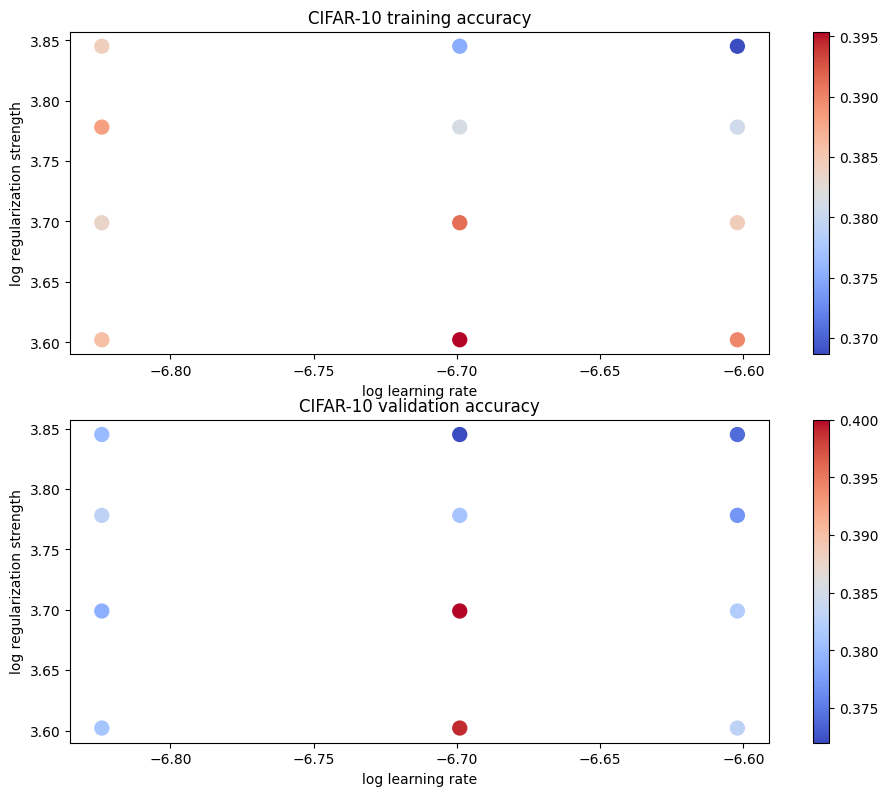

In [16]:
# 可视化交叉验证结果
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# 绘制训练准确率
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# 绘制验证准确率
colors = [results[x][1] for x in results] # 默认 marker 大小为 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [17]:
# 在测试集上评估最佳 svm
y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('linear SVM on raw pixels final test set accuracy: %f' % test_accuracy)

linear SVM on raw pixels final test set accuracy: 0.392000


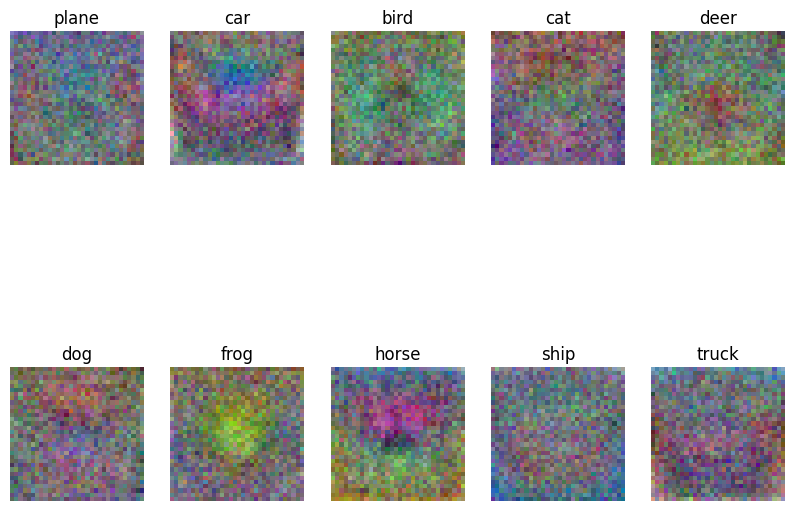

: 

In [ ]:
# 可视化每个类别学习到的权重。
# 根据您的学习率和正则化强度的选择，这些权重可能看起来不错，也可能不那么好。
w = best_svm.W[:-1,:] # 去掉偏置
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)
      
    # 将权重缩放到 0 到 255 之间
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**内嵌问题 2**

描述你可视化的 SVM 权重长什么样，并简要解释为什么它们长这样。

$\color{blue}{\textit 你的答案:}$ SVM 权重是10张模糊的图片，模型会去拟合训练数据，每张图片看起来像是该类别所有样本的平均值，带有噪点。

<details><summary>英文原文</summary>

**Inline question 2**

Describe what your visualized SVM weights look like, and offer a brief explanation for why they look the way they do.

$\color{blue}{\textit Your Answer:}$ *fill this in*  

</details>